# QS-Net
## Version 1.0

This notebook implements the three QS-Net algorithms, incorporating 3 different algorithms:

1. **Algorithm 1 (MAQT)** shapes Hilbert-space geometry with cross-entropy + intra/inter prototype losses.
2. **Algorithm 2 (CQ-ZDR)** sets a conformal zero-day threshold from known-class calibration data.
3. **Algorithm 3 (Inference)** classifies with a certified radius or flags `ZERO_DAY`.

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

## Load Dataset: TON IoT

In [2]:
df = pd.read_parquet("data/TON_IoT/quantum/q8_train.parquet")
df

,dst_pkts,protocol,src_pkts,dst_bytes,n_bytes_total,src_bytes,conn_state,duration,label_multiclass,label_binary,label_family
0,0.529836,3.141593,0.556692,1.088846,0.957560,0.758171,3.141593,0.005108,password,1.0,bruteforce_password
1,0.575419,3.141593,0.556692,1.082288,0.987983,0.828671,3.141593,0.017505,injection,1.0,web_injection
2,0.780388,3.141593,0.556692,1.344399,1.152061,0.873394,3.141593,0.535346,ddos,1.0,ddos
3,0.204968,0.836286,0.215358,0.568380,0.594294,0.591666,3.141593,0.001233,password,1.0,bruteforce_password
4,0.529836,3.141593,0.556692,0.901747,0.852190,0.750624,3.141593,0.000617,normal,0.0,benign
...,...,...,...,...,...,...,...,...,...,...,...
60303,0.000000,0.836286,0.430716,0.000000,0.360470,0.747692,3.141593,0.254447,NaN,NaN,NaN
60304,0.614905,3.141593,0.556692,1.165812,1.040995,0.844430,3.141593,0.023131,NaN,NaN,NaN
60305,0.900286,3.141593,1.066925,1.201364,1.140813,1.011379,3.141593,1.428035,NaN,NaN,NaN
60306,0.000000,3.141593,1.490032,0.000000,0.000000,0.000000,3.141593,0.069285,NaN,NaN,NaN


In [3]:
print(df["label_multiclass"].unique())
print()
print(df["label_family"].unique())

<ArrowStringArray>
[ 'password', 'injection',      'ddos',    'normal',       'xss',  'scanning',
  'backdoor',      'mitm',       'dos',         nan]
Length: 10, dtype: str

<ArrowStringArray>
[        'bruteforce_password',               'web_injection',
                        'ddos',                      'benign',
                       'recon', 'backdoor_malware_ransomware',
               'spoofing_mitm',                         'dos',
                           nan]
Length: 9, dtype: str


In [4]:
# check rows if NaN dropped in the label_multiclass column
df[df["label_multiclass"].notna()].copy()

,dst_pkts,protocol,src_pkts,dst_bytes,n_bytes_total,src_bytes,conn_state,duration,label_multiclass,label_binary,label_family
0,0.529836,3.141593,0.556692,1.088846,0.957560,0.758171,3.141593,0.005108,password,1.0,bruteforce_password
1,0.575419,3.141593,0.556692,1.082288,0.987983,0.828671,3.141593,0.017505,injection,1.0,web_injection
2,0.780388,3.141593,0.556692,1.344399,1.152061,0.873394,3.141593,0.535346,ddos,1.0,ddos
3,0.204968,0.836286,0.215358,0.568380,0.594294,0.591666,3.141593,0.001233,password,1.0,bruteforce_password
4,0.529836,3.141593,0.556692,0.901747,0.852190,0.750624,3.141593,0.000617,normal,0.0,benign
...,...,...,...,...,...,...,...,...,...,...,...
41490,0.529836,3.141593,0.604586,1.112493,1.097880,1.022555,3.141593,0.000815,normal,0.0,benign
41491,0.529836,3.141593,0.646074,1.092155,0.994987,0.832071,3.141593,0.232142,normal,0.0,benign
41492,0.885859,3.141593,0.987408,0.988759,1.053146,1.069316,3.141593,1.413128,injection,1.0,web_injection
41493,0.575419,3.141593,0.556692,1.165812,1.037165,0.836487,3.141593,0.038636,normal,0.0,benign


In [5]:
# get labels
class_names = sorted(df["label_multiclass"].dropna().unique())
class_names

['backdoor',
 'ddos',
 'dos',
 'injection',
 'mitm',
 'normal',
 'password',
 'scanning',
 'xss']

In [6]:
def load_split(name, categories):
    df = pd.read_parquet(f"data/TON_IoT/quantum/q8_{name}.parquet")
    df = df[df["label_multiclass"].notna()].copy()

    feature_cols = [c for c in df.columns if not c.startswith("label")]
    X = df[feature_cols].values
    y = pd.Categorical(df["label_multiclass"], categories=categories).codes

    return X, y

In [7]:
def stratified_head(X, y, n, seed=42):
    """
    Take a stratified subset of size n (or all if n >= len(X))
    """
    if n >= len(X):
        return X.copy(), y.copy()
    _, X_sub, _, y_sub = train_test_split(
        X, y, test_size=n, stratify=y, random_state=seed
    )
    return X_sub, y_sub

In [8]:
# load all data
X_train_full, y_train_full = load_split("train", class_names)
X_cal_full, y_cal_full = load_split("calibration", class_names)
X_test_full, y_test_full = load_split("test", class_names)
X_val_full, y_val_full = load_split("val", class_names)

In [9]:
# take subset
X_train, y_train = stratified_head(X_train_full, y_train_full, 2000, seed=42)
X_cal, y_cal = stratified_head(X_cal_full, y_cal_full, 50, seed=42)
X_test, y_test = stratified_head(X_test_full, y_test_full, 200, seed=43)
X_val = X_val_full[:]
y_val = y_val_full[:]

In [10]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([(2000, 8), (2000,)],
 [(50, 8), (50,)],
 [(200, 8), (200,)],
 [(784, 8), (784,)])

In [11]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"classes: {class_names}")
print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

classes: ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'scanning', 'xss']
number of classes: 9
number of qubits: 8


## Angle Encoding with Data Reuploading

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform

Source: https://pennylane.ai/demos/tutorial_data_reuploading_classifier

In [12]:
# initialize device
dev = qp.device("default.qubit", wires=num_qubits)

In [13]:
# reupload same classical data 2 times
num_layers = 2

In [14]:
def initialize_weights(n_layers, n_wires):
    """
    Initialize weights for the variational circuit using identity rotations to be barren-plateau-safe.
    """
    shape = qp.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_wires)
    return np.zeros(shape, requires_grad=True)

In [15]:
# initialize weights
weights = initialize_weights(num_layers, num_qubits)
weights.shape

(2, 8, 3)

In [16]:
# DEBUG
weights

tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], requires_grad=True)

In [17]:
@qp.qnode(dev)
def statevector_circuit(x, theta):
    """
    Circuit for encoding and variational quantum circuit.
    """
    for layer in range(num_layers):
        qp.AngleEmbedding(x, wires=range(num_qubits), rotation="Y") # phi(x): encode
        qp.StronglyEntanglingLayers(theta[layer : layer + 1], wires=range(num_qubits)) # U(theta): variational
    return qp.state()

## Noise

QS-Net methodology uses a standard depolarization channel to model NISQ noise:

$$
\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})
$$

For one qubit ($d=2^1=2$), the depolarizing channel is:

$$
\Lambda_p(\rho) = (1-p)\,\rho + \frac{p}{2}\,I_2
$$

Applied to the pure circuit output:

$$
\rho(x) = \Lambda_p\bigl(\ket{\Phi(x)}\bra{\Phi(x)}\bigr)
= (1-p)\,\ket{\Phi(x)}\bra{\Phi(x)} + \frac{p}{2}\,I_2
$$

where $I_2 = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$ and $p \in [0,1]$.

Source: Nielsen, M. A. & Chuang., I. L. (2010). [Quantum computation and quantum information](https://profmcruz.wordpress.com/wp-content/uploads/2017/08/quantum-computation-and-quantum-information-nielsen-chuang.pdf). p-378.

In [18]:
def lambda_p(rho, p):
    """
    Add noise to the quantum state.
    """
    dim = rho.shape[0]
    return (1.0 - p) * rho + p * np.eye(dim) / dim

In [19]:
def noised_quantum_state(x, theta, p=0.01): # p = noise_rate
    """
    Get the noised quantum state.
    """
    psi = statevector_circuit(x, theta) # |Phi(x)>
    rho = qp.math.dm_from_state_vector(psi) # |Phi(x)><Phi(x)|
    return lambda_p(rho, p)

## Measurement

In [20]:
def measure_logits(rho):
    """
    Measure the logits of the quantum state.
    """
    logits = []
    for j in range(num_qubits):
        Z = qp.matrix(qp.PauliZ(j), wire_order=range(num_qubits))
        logits.append(np.real(np.trace(rho @ Z)))
    X = qp.matrix(qp.PauliX(0), wire_order=range(num_qubits)) # 9th logit
    logits.append(np.real(np.trace(rho @ X)))
    return np.array(logits)

In [21]:
def softmax(x):
    """
    Softmax activation function.
    """
    x = np.array(x)
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

## Algo 1: Margin-Aware Quantum Training (MAQT)

### Class Prototypes

For each known class $c$, the average (mixed) quantum state of its training samples becomes the prototype density matrix $\rho_c$, the cluster centre in Hilbert space.

$$
\rho_c = \frac{1}{|D_c|} \sum_{x_i \in D_c} \rho(x_i)
$$

- $D_c$: training samples with label $c$
- $\rho(x_i)$: noisy density matrix for sample $x_i$
- $\rho_c$: mixed state prototype

In [22]:
class PrototypeBank:
    """Running average of rho(x) per class during MAQT minibatches."""

    def __init__(self, classes):
        self.classes = sorted(classes)
        self._sums = {c: None for c in self.classes}
        self._counts = {c: 0 for c in self.classes}

    def reset(self):
        self._sums = {c: None for c in self.classes}
        self._counts = {c: 0 for c in self.classes}

    def update(self, label, rho):
        rho_np = np.array(rho)
        if self._sums[label] is None:
            self._sums[label] = rho_np
        else:
            self._sums[label] = self._sums[label] + rho_np
        self._counts[label] += 1

    def means(self):
        return {
            c: self._sums[c] / self._counts[c]
            for c in self.classes
            if self._counts[c] > 0
        }

In [23]:
def compute_prototypes(theta, X, y, classes):
    """
    Build final class prototypes by averaging noisy states over training samples.
    """
    bank = PrototypeBank(classes)
    for x, label in zip(X, y):
        bank.update(int(label), noised_quantum_state(x, theta))
    return bank.means()

In [24]:
def prototype_summary(prototypes, class_names=None):
    """
    Summarize the prototype density matrices.
    """
    rows = []
    for c in sorted(prototypes):
        rho_c = prototypes[c]
        name = class_names[c] if class_names is not None else str(c)
        rows.append({
            "class": name,
            "dim": rho_c.shape[0],
            "trace": float(np.trace(rho_c)),
        })
    return rows

### Loss Function

$$
L = L_{CE} + \lambda_1 L_{intra} + \lambda_2 L_{inter}
$$

- **$L_{CE}$**: cross-entropy on $\rho(x)$
- **$L_{intra}$**: average infidelity $(1 - fidelity)$ between each sample's state and its class prototype. It describes how far each $\rho(x)$ is from its own class prototype $\rho_c$.
- **$L_{inter}$**: Negative average trace distance between prototypes of different classes.
It describes how close different class prototypes $\rho_c$ and $\rho_{c'}$ are to each other.

In [25]:
def fidelity(rho_a, rho_b):
    """
    Compute the fidelity between two density matrices.
    """
    return qp.math.fidelity(rho_a, rho_b)

In [26]:
def trace_distance(rho_a, rho_b):
    """
    Compute the trace distance between two density matrices.
    """
    return qp.math.trace_distance(rho_a, rho_b)

In [27]:
def maqt_loss(theta, X_batch, y_batch, prototypes, lambda1=0.5, lambda2=0.3):
    """
    MAQT loss function.
    """
    ce = 0.0
    intra_terms = {c: [] for c in prototypes}

    # compute the cross-entropy loss
    for x, y_i in zip(X_batch, y_batch):
        rho_x = noised_quantum_state(x, theta)
        probs = softmax(measure_logits(rho_x))
        ce -= np.log(probs[int(y_i)] + 1e-10)

        proto = prototypes[int(y_i)]
        intra_terms[int(y_i)].append(1.0 - fidelity(rho_x, proto))

    l_ce = ce / len(X_batch)

    # compute the intra-class (within-class) fidelity
    l_intra = 0.0
    for c, terms in intra_terms.items():
        if terms:
            l_intra += np.mean(np.array(terms))
    active_classes = [c for c, terms in intra_terms.items() if terms]
    if active_classes:
        l_intra /= len(active_classes)

    # compute the inter-class (between-class) trace distance
    class_list = sorted(prototypes.keys())
    inter_pairs = []
    for i, c in enumerate(class_list):
        for c_prime in class_list[i + 1 :]:
            inter_pairs.append(trace_distance(prototypes[c], prototypes[c_prime]))
    l_inter = -np.mean(np.array(inter_pairs)) if inter_pairs else 0.0

    return l_ce + lambda1 * l_intra + lambda2 * l_inter

In [28]:
def gradient_variance(theta, X_batch, y_batch, prototypes):
    """
    Compute the gradient variance of the MAQT loss function.
    """
    grad_fn = qp.grad(lambda w: maqt_loss(w, X_batch, y_batch, prototypes))
    grads = grad_fn(theta)
    flat = np.array(grads).reshape(-1)
    return float(np.var(flat)), grads

### Training

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [29]:
noise_rate = 0.01
lambda1 = 0.5   # L_intra weight
lambda2 = 0.3   # L_inter weight
epochs = 10
batch_size = 64
lr = 0.01
barren_plateau_var = 1e-6

In [30]:
opt = qp.AdamOptimizer(stepsize=lr)
prototype_bank = PrototypeBank(range(num_classes))
history = {
    "loss": [],
    "l_ce": [],
    "grad_var": [],
    "barren_plateau": [],
}

num_batches = (len(X_train) + batch_size - 1) // batch_size
print(f"training: {len(X_train)} samples, {num_batches} batches/epoch, {epochs} epochs")

for epoch in range(epochs):
    prototype_bank.reset()
    perm = np.random.permutation(len(X_train))
    X_shuf = X_train[perm]
    y_shuf = y_train[perm]

    epoch_grad_vars = []

    for batch_idx, start in enumerate(range(0, len(X_shuf), batch_size)):
        print(f"epoch {epoch + 1} batch {batch_idx}/{num_batches - 1}")

        X_batch = X_shuf[start : start + batch_size]
        y_batch = y_shuf[start : start + batch_size]

        # running prototype update for classes present in this batch
        for x, label in zip(X_batch, y_batch):
            prototype_bank.update(int(label), noised_quantum_state(x, weights))
        batch_prototypes = prototype_bank.means()

        # update weights
        weights, batch_loss = opt.step_and_cost(
            lambda w: maqt_loss(w, X_batch, y_batch, batch_prototypes),
            weights,
        )

        # compute gradient variance
        gvar, _ = gradient_variance(weights, X_batch, y_batch, batch_prototypes)
        epoch_grad_vars.append(gvar)

    full_loss = maqt_loss(weights, X_train, y_train, prototypes)
    mean_gvar = float(np.mean(epoch_grad_vars)) if epoch_grad_vars else 0.0
    plateau = mean_gvar < barren_plateau_var

    history["loss"].append(float(full_loss))
    history["grad_var"].append(mean_gvar)
    history["barren_plateau"].append(plateau)

    print(
        f"epoch {epoch + 1:02d}/{epochs} | loss={full_loss:.4f} | "
        f"grad_var={mean_gvar:.2e} | barren_plateau={plateau}"
    )

theta_star = weights
prototypes = compute_prototypes(theta_star, X_train, y_train, range(num_classes)) # recompute final prototypes over all of D

training: 2000 samples, 32 batches/epoch, 10 epochs
epoch 1 batch 0/31
epoch 1 batch 1/31
epoch 1 batch 2/31
epoch 1 batch 3/31
epoch 1 batch 4/31
epoch 1 batch 5/31
epoch 1 batch 6/31
epoch 1 batch 7/31
epoch 1 batch 8/31
epoch 1 batch 9/31
epoch 1 batch 10/31
epoch 1 batch 11/31
epoch 1 batch 12/31
epoch 1 batch 13/31
epoch 1 batch 14/31
epoch 1 batch 15/31
epoch 1 batch 16/31
epoch 1 batch 17/31
epoch 1 batch 18/31
epoch 1 batch 19/31
epoch 1 batch 20/31
epoch 1 batch 21/31
epoch 1 batch 22/31
epoch 1 batch 23/31
epoch 1 batch 24/31
epoch 1 batch 25/31
epoch 1 batch 26/31
epoch 1 batch 27/31
epoch 1 batch 28/31
epoch 1 batch 29/31
epoch 1 batch 30/31
epoch 1 batch 31/31
epoch 01/10 | loss=2.5307 | grad_var=2.16e-04 | barren_plateau=False
epoch 2 batch 0/31
epoch 2 batch 1/31
epoch 2 batch 2/31
epoch 2 batch 3/31
epoch 2 batch 4/31
epoch 2 batch 5/31
epoch 2 batch 6/31
epoch 2 batch 7/31
epoch 2 batch 8/31
epoch 2 batch 9/31
epoch 2 batch 10/31
epoch 2 batch 11/31
epoch 2 batch 12/31

In [31]:
# DEBUG
weights

tensor([[[ 0.        ,  1.13069327,  0.        ],
         [ 0.        ,  1.07519302,  0.        ],
         [ 0.        , -0.1043689 ,  0.        ],
         [ 0.        ,  1.06224618,  0.        ],
         [ 0.        ,  0.94622032,  0.        ],
         [ 0.        , -0.68601691,  0.        ],
         [ 0.        ,  0.46108805,  0.        ],
         [ 0.        ,  0.5779692 ,  0.        ]],

        [[ 0.        ,  1.09865483,  0.        ],
         [ 0.        , -0.7771851 ,  0.        ],
         [ 0.        ,  0.10623356,  0.        ],
         [ 0.        ,  0.95873192,  0.        ],
         [ 0.        , -0.72303074,  0.        ],
         [ 0.        , -0.66921082,  0.        ],
         [ 0.        ,  0.60382331,  0.        ],
         [ 0.        ,  1.02260577,  0.        ]]], requires_grad=True)

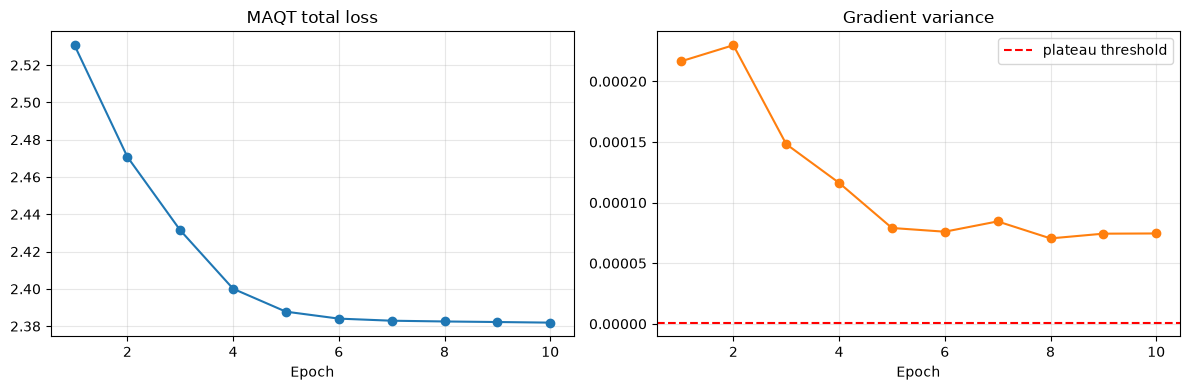

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs + 1), history["loss"], marker="o")
axes[0].set_title("MAQT total loss")
axes[0].set_xlabel("Epoch")
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, epochs + 1), history["grad_var"], marker="o", color="tab:orange")
axes[1].axhline(barren_plateau_var, color="red", linestyle="--", label="plateau threshold")
axes[1].set_title("Gradient variance")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Algo 2: Conformal Zero-Day Threshold Calibration (CQ-ZDR)

Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.

Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

In [33]:
def nonconformity_score(x, theta, prototypes):
    """
    Nonconformity score.
    """
    rho_x = noised_quantum_state(x, theta)
    fidelities = [fidelity(rho_x, prototypes[c]) for c in sorted(prototypes)]
    return 1.0 - max(fidelities)

In [34]:
def calibrate_threshold(theta, X_cal, prototypes, alpha=0.05):
    """
    Calibrate the threshold.
    """
    scores = np.array([nonconformity_score(x, theta, prototypes) for x in X_cal])
    scores_sorted = np.sort(scores)
    n = len(scores_sorted)
    k = int(np.ceil((1.0 - alpha) * (n + 1))) - 1   # convert 1-based index to 0-based
    k = min(max(k, 0), n - 1)   # clip to valid index
    q = float(scores_sorted[k])
    return q, scores_sorted

In [35]:
alpha = 0.05
q, scores_sorted = calibrate_threshold(theta_star, X_cal, prototypes, alpha=alpha)
print(f"conformal threshold q = {q:.4f} (alpha={alpha}, n_cal={len(X_cal)})")

conformal threshold q = 0.8809 (alpha=0.05, n_cal=50)


## Algo 3: Unified Inference with Disentangled Rejection

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

In [36]:
L_phi = 1.0 # encoder Lipschitz constant
Cf = 1.0    # contraction constant from Proposition 1
ZERO_DAY = -1

In [37]:
def qsnet_infer(x, theta, prototypes, q, p=noise_rate, L_phi=L_phi, Cf=Cf):
    """
    Unified inference with disentangled rejection.
    """
    rho_x = noised_quantum_state(x, theta, p=p)
    class_ids = sorted(prototypes.keys())
    f_map = {c: fidelity(rho_x, prototypes[c]) for c in class_ids}
    f_vals = np.array([f_map[c] for c in class_ids])

    c_star = class_ids[int(np.argmax(f_vals))]
    s = 1.0 - f_map[c_star]

    if s > q:
        return ZERO_DAY, 0.0, s, f_map

    sorted_f = np.sort(f_vals)
    margin = sorted_f[-1] - sorted_f[-2]
    radius = margin / (2.0 * (1.0 - p) * L_phi * Cf)
    return c_star, float(radius), s, f_map

## Evaluation

In [38]:
def predict_batch(X, theta, prototypes, q):
    """
    Make batch predictions.
    """
    labels, radii, scores = [], [], []
    for x in X:
        label, radius, score, _ = qsnet_infer(x, theta, prototypes, q)
        labels.append(label)
        radii.append(radius)
        scores.append(score)
    return np.array(labels), np.array(radii), np.array(scores)

## Evaluation on Known Test Samples

known-sample accuracy (non-rejected): 0.021
rejection rate on test: 0.055
mean certified radius (accepted): 0.0179

classification report (accepted predictions only):
              precision    recall  f1-score   support

    backdoor       0.00      0.00      0.00         0
        ddos       0.00      0.00      0.00        23
         dos       0.05      0.33      0.09        12
   injection       0.00      0.00      0.00        42
        mitm       0.00      0.00      0.00         2
      normal       0.00      0.00      0.00        48
    password       0.00      0.00      0.00        35
    scanning       0.00      0.00      0.00         7
         xss       0.00      0.00      0.00        20

    accuracy                           0.02       189
   macro avg       0.01      0.04      0.01       189
weighted avg       0.00      0.02      0.01       189



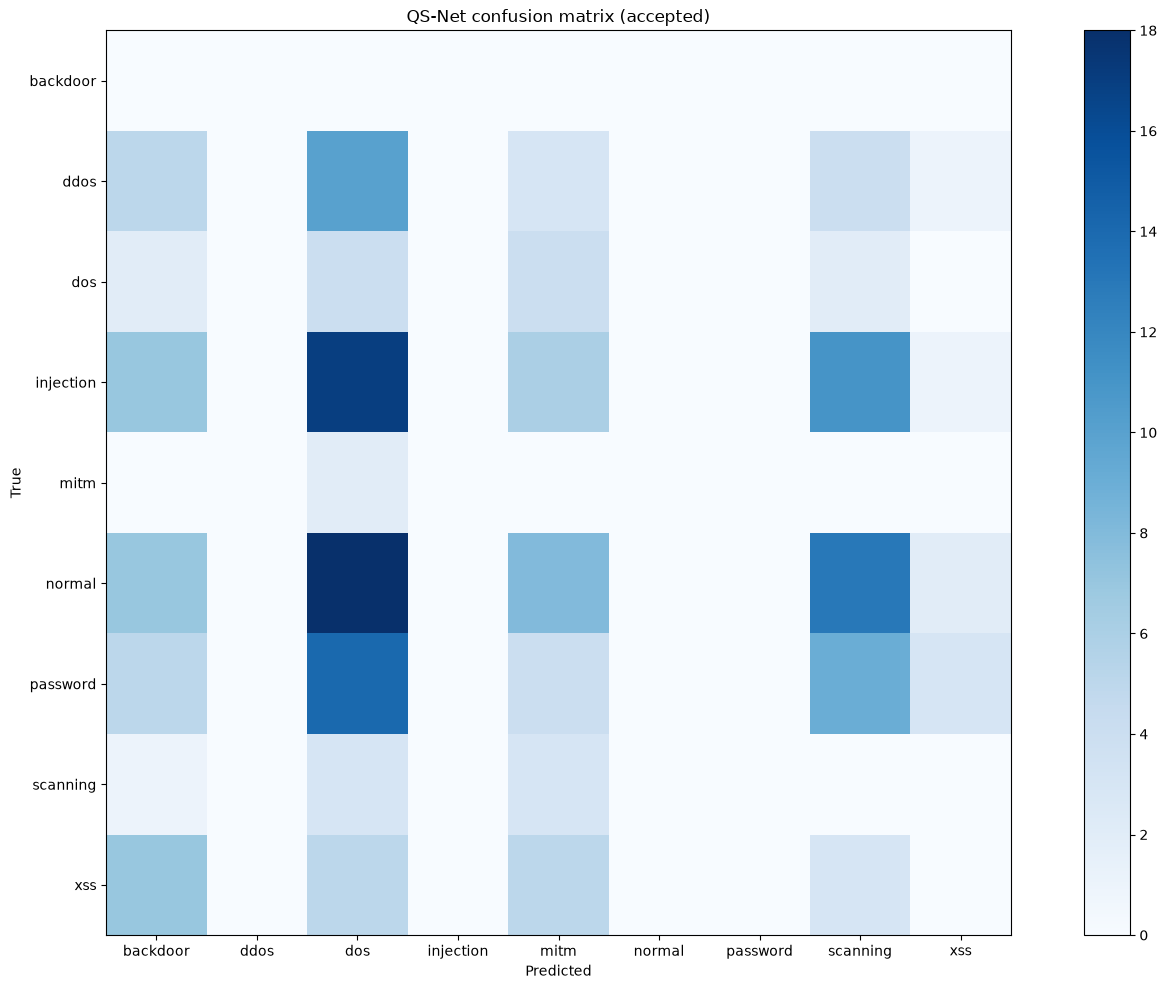

In [39]:
y_pred, radii, novelty_scores = predict_batch(X_test, theta_star, prototypes, q)

known_mask = y_pred != ZERO_DAY
known_acc = np.mean(y_pred[known_mask] == y_test[known_mask]) if known_mask.any() else 0.0
reject_rate = 1.0 - known_mask.mean()

print(f"known-sample accuracy (non-rejected): {known_acc:.3f}")
print(f"rejection rate on test: {reject_rate:.3f}")
print(f"mean certified radius (accepted): {radii[known_mask].mean():.4f}")

if known_mask.any():
    print("\nclassification report (accepted predictions only):")
    print(classification_report(
        y_test[known_mask], y_pred[known_mask], labels=list(range(num_classes)), target_names=class_names, zero_division=0
    ))

    cm = confusion_matrix(y_test[known_mask], y_pred[known_mask])
    fig, ax = plt.subplots(figsize=(15, 10))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="QS-Net confusion matrix (accepted)",
    )
    plt.tight_layout()
    plt.show()

## References

- Importing PennyLane as qp: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml
- Encoding data in angles: https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html
- Data reuploading: https://pennylane.ai/demos/tutorial_data_reuploading_classifier
- Strong entangling layers: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html
- Standard depolarization: https://profmcruz.wordpress.com/wp-content/uploads/2017/08/quantum-computation-and-quantum-information-nielsen-chuang.pdf, p-378.